In [ ]:
from pathlib import Path
from src.Elements import Elements
from src.models import VisionTransformer, VisionTransformerCNN
from torchview import draw_graph
import graphviz 
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH = Path("data/model_weights/VisionTransformer--2025-04-25--17-56-44")
# from src.models import VisionTransformer
# input_size = 4096
# patch_size = 256
# embed_dim = 256 
# num_heads = 8 
# num_classes = len(Elements.LINES) 
# num_layers = 6 
# hidden_dim = 4 * embed_dim
# dropout_rate = 0.1

# model = VisionTransformer(input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate).to(device)

# from src.models import XRFClassifier
# PATH = Path("data/model_weights/XRFClassifier--2025-04-24--21-01-27")
# model = XRFClassifier(len(Elements.LINES.keys())).to(device)

input_size = 4096
patch_size = 256
embed_dim = 256 
num_heads = 8 
num_classes = len(Elements.LINES) 
num_layers = 6 
hidden_dim = 4 * embed_dim
dropout_rate = 0.1

model = VisionTransformerCNN(input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate).to(device)
PATH = Path("data/model_weights/VisionTransformerCNN--2025-04-24--23-36-19")

model.load_state_dict(torch.load(PATH, weights_only=True, map_location=device))
model.eval()

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graph = draw_graph(model, input_size=(64, 1, 4096))
graphviz.set_jupyter_format('png')

# object = np.load("data/processed/matka_boska_10x10_patches.npz", allow_pickle=True)
object = np.load("data/objects/processed/matka_boska_1x1_patches.npz", allow_pickle=True)
print(object)

torch.Size([16])
4813328
NpzFile 'data/objects/processed/matka_boska_1x1_patches.npz' with keys: e_xy, peaks, peak_energies


In [3]:
# from sklearn.model_selection import train_test_split
# from src.EvaluationUtils import EvaluationUtils
# import numpy as np

# X = np.load("data/semi_artifficial_test/X.npy")
# y = np.load("data/semi_artifficial_test/y.npy")
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)
# testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 128)

# import matplotlib.pyplot as plt
# import numpy as np

# def np_arr(batch: torch.Tensor) -> np.ndarray:
#     return batch.cpu().squeeze().detach().numpy()

# for i, (X_batch, y_batch) in enumerate(testloader):
#     X_true, y_true = np_arr(X_batch[0]), np_arr(y_batch[0])
#     y_pred = np_arr(model(X_batch)[0])
#     y_pred[y_pred < 0.5] = 0

#     true_label = ", ".join([f"{Elements.NUM2SYMBOL[i]}: {v:.2f}" for i, v in enumerate(y_true) if v > 0])
#     pred_label = ", ".join([f"{Elements.NUM2SYMBOL[i]}: {v:.2f}" for i, v in enumerate(y_pred) if v > 0])
#     plt.figure(i)
#     plt.plot(X_true, label=f"True labels: {true_label}")
#     plt.plot(X_true, label=f"Pred labels: {pred_label}")
#     plt.legend()
#     if i == 10:
#         break

import matplotlib.pyplot as plt

def increase_contrast(image, factor=1.5):
    """
    Increases the contrast of a single-channel image.
    
    Parameters:
        image (numpy.ndarray): Input image with values in range [0, 1].
        factor (float): Contrast adjustment factor. Greater than 1 increases contrast.
    
    Returns:
        numpy.ndarray: Contrast-enhanced image, clipped to [0, 1].
    """
    mean = np.mean(image)  # Compute mean intensity
    contrasted = (image - mean) * factor + mean  # Apply contrast adjustment
    return np.clip(contrasted, 0, 1)  # Ensure values remain in [0, 1]

def downsample_average(image, factor=32):
    """
    Downsamples a single-channel image by a given factor using block averaging.

    Parameters:
        image (numpy.ndarray): Input image (H, W) with values in range [0, 1].
        factor (int): Downsampling factor.

    Returns:
        numpy.ndarray: Downsampled image.
    """
    H, W = image.shape
    H_new, W_new = H // factor, W // factor  # New size
    return image[:H_new * factor, :W_new * factor].reshape(H_new, factor, W_new, factor).max(axis=(1, 3))


In [4]:
import math 
e_xy = object["e_xy"]
H, W, C = e_xy.shape
e_xy = e_xy.reshape(-1, C)
batch_size = 128
batches = math.ceil(len(e_xy) / batch_size)

outputs = []
with torch.no_grad():
    model.eval()
    for i in range(0, batches):
        print(i)
        batch = torch.tensor(e_xy[i*batch_size:min(i*batch_size + batch_size, e_xy.shape[0])], dtype=torch.float).to(device).unsqueeze(1)
        outputs.extend([model(batch)])

outputs = torch.cat(outputs, dim=0).reshape(H, W, -1)
e_xy = e_xy.reshape(H, W, C)
# print("Output shape:", final_output.shape) 


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

/tmp/ipykernel_614673/634384050.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


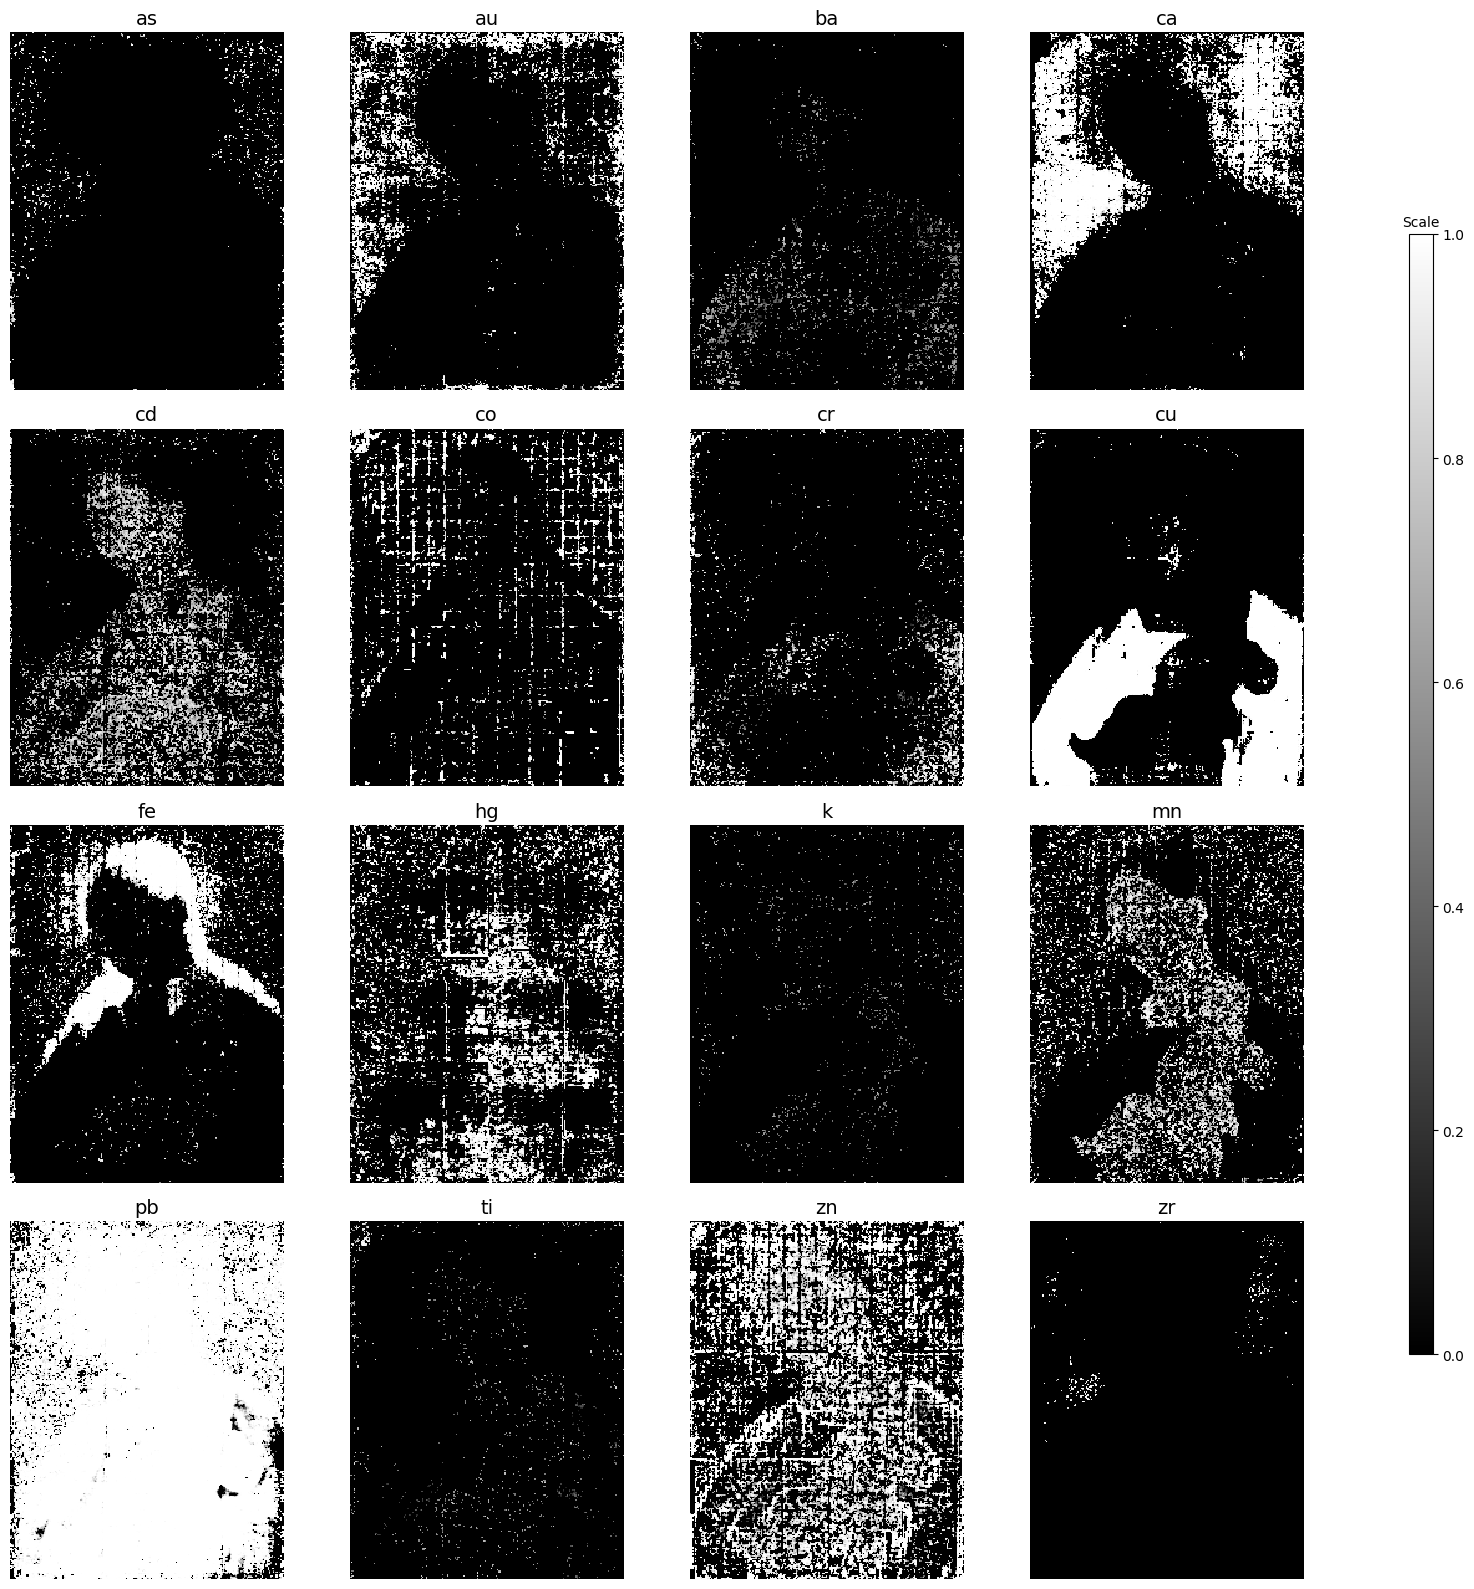

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from skimage.filters import median

# Move tensor to CPU and detach
outputs = outputs.cpu().detach()

# Get top 3 indices at each (x, y) across all slices
topk_vals, topk_indices = torch.topk(outputs, k=3, dim=-1)

# Create a mask to keep only top 3 values
mask = torch.zeros_like(outputs, dtype=torch.bool)
H, W, D = outputs.shape
x = torch.arange(H).view(-1, 1, 1)
y = torch.arange(W).view(1, -1, 1)
x, y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing='ij')

for i in range(3):
    mask[x, y, topk_indices[:, :, i]] = True

# Mask outputs to keep only top 3
masked_outputs = torch.where(mask, outputs, torch.tensor(float('nan')))

# Normalize based on original min/max
global_min = outputs.min().item()
global_max = outputs.max().item()
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)
cmap = plt.cm.gray

rgba_tensor = cmap(norm(masked_outputs.numpy()))
rgba_tensor[np.isnan(masked_outputs.numpy())] = [0, 0, 0, 1]  # optional: make non-top3 black

# Plotting
num_slices = outputs.shape[-1]
cols = int(np.ceil(np.sqrt(num_slices)))
rows = int(np.ceil(num_slices / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i in range(num_slices):
    ax = axes[i]
    ax.imshow(rgba_tensor[:, :, i], interpolation="nearest")
    ax.axis("off")
    ax.set_title(f"{Elements.NUM2SYMBOL[i]}", fontsize=14)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.ax.set_title("Scale", fontsize=10)

fig.tight_layout(rect=[0, 0, 0.9, 1])
fig.savefig("top3_slices_shared_scale.png", dpi=300)
plt.show()

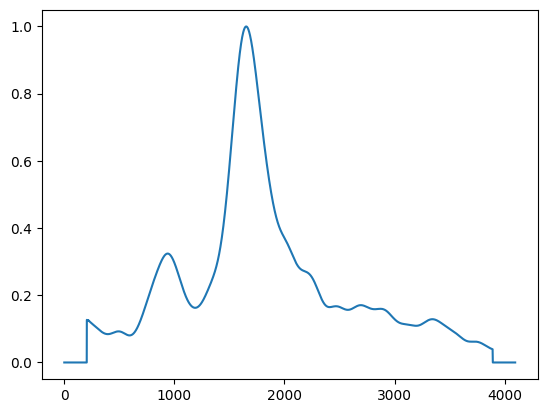

In [6]:
plt.plot(e_xy[10, 10])